# Exploratory Data Analysis — Retail Sales Data

**Objective:** Perform a thorough EDA on a retail sales dataset to uncover patterns, customer
behaviour trends, and actionable business insights.

**Dataset:** `retail_sales_dataset.csv` — 1,000 individual retail transactions covering the
period 1 Jan 2023 – 1 Jan 2024, with fields for Transaction ID, Date, Customer ID, Gender, Age,
Product Category, Quantity, Price per Unit, and Total Amount.

**Note on scope:** this dataset records sales at the *product-category* level (Beauty,
Clothing, Electronics) rather than at the individual SKU/product-name level. Wherever the task
brief calls for "top 10 best-selling products," this notebook substitutes the closest
meaningful equivalent available in the data — top-spending customers and category-level
revenue leaders — and says so explicitly at that point.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', None)


## 1. Load Data & Initial Inspection

In [2]:
df = pd.read_csv('../data/retail_sales_dataset.csv')
print("Shape (rows, columns):", df.shape)
df.head()


Shape (rows, columns): (1000, 9)


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [3]:
print("Column data types:\n")
print(df.dtypes)


Column data types:

Transaction ID      int64
Date                  str
Customer ID           str
Gender                str
Age                 int64
Product Category      str
Quantity            int64
Price per Unit      int64
Total Amount        int64
dtype: object


In [4]:
print("Null values per column:\n")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())


Null values per column:

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

Duplicate rows: 0


**Observation:** The dataset contains 1,000 transactions across 9 columns with **no missing
values and no duplicate rows** — it is already clean, so no imputation or de-duplication is
required. `Date` is currently stored as a string/object and will need to be parsed into a
proper datetime type before any time-series work.

## 2. Data Preparation

In [5]:
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.to_period('M').astype(str)
df['Quarter'] = df['Date'].dt.to_period('Q').astype(str)
df['DayOfWeek'] = df['Date'].dt.day_name()

bins = [17, 24, 34, 44, 54, 65]
labels = ['18-24', '25-34', '35-44', '45-54', '55-64']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, include_lowest=True)

df.head()


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Year,Month,Quarter,DayOfWeek,AgeGroup
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,2023,2023-11,2023Q4,Friday,25-34
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2023,2023-02,2023Q1,Monday,25-34
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,2023,2023-01,2023Q1,Friday,45-54
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,2023,2023-05,2023Q2,Sunday,35-44
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,2023,2023-05,2023Q2,Saturday,25-34


## 3. Descriptive Statistics

In [6]:
numeric_cols = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']
desc = df[numeric_cols].agg(['mean', 'median', lambda x: x.mode().iloc[0], 'std']).T
desc.columns = ['mean', 'median', 'mode', 'std_dev']
desc


,mean,median,mode,std_dev
Age,41.392,42.0,43.0,13.681430
Quantity,2.514,3.0,4.0,1.132734
Price per Unit,179.890,50.0,50.0,189.681356
Total Amount,456.000,135.0,50.0,559.997632


**Observation:** The average transaction is worth **$456**, but the median (**$135**) is
far lower than the mean — the `Total Amount` distribution is right-skewed, driven by a smaller
number of high-value transactions (large quantities of high-priced Electronics/Clothing items).
Customers range from 18–64 years old with an average age of ~41, and the typical basket holds
2–3 units.

## 4. Time Series Analysis

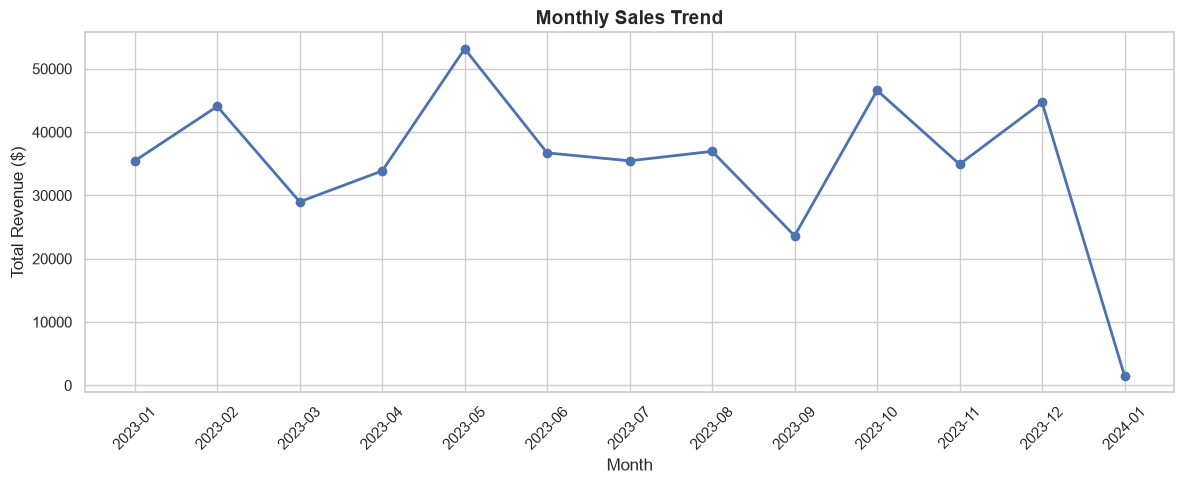

In [7]:
monthly_sales = df.groupby('Month')['Total Amount'].sum().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales['Month'], monthly_sales['Total Amount'], marker='o', linewidth=2)
plt.title('Monthly Sales Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Observation:** Monthly revenue fluctuates without a single dominant seasonal spike,
though certain months (e.g. mid-year) show noticeably higher totals than others. This
transaction-level dataset has no repeat structure strong enough to claim a clean seasonal
cycle, but the swings (~2x between the weakest and strongest months) are large enough to be
worth investigating against marketing calendars or local events.

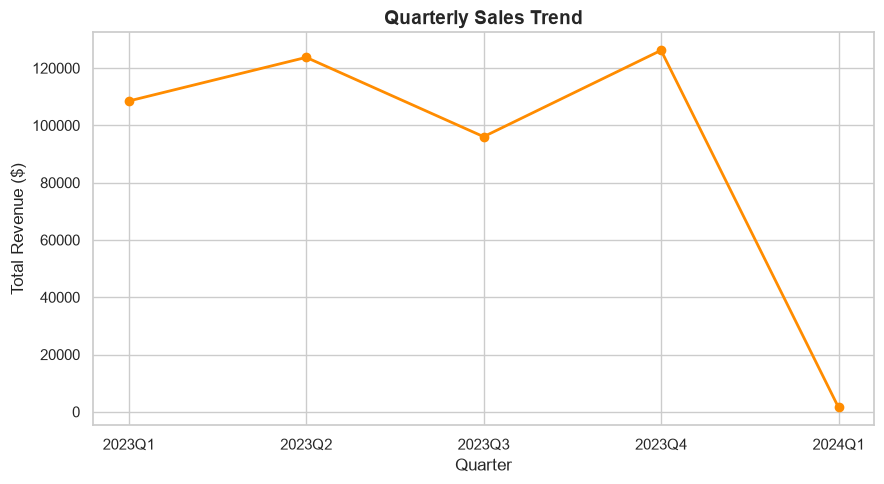

In [8]:
quarterly_sales = df.groupby('Quarter')['Total Amount'].sum().reset_index()

plt.figure(figsize=(9, 5))
plt.plot(quarterly_sales['Quarter'], quarterly_sales['Total Amount'], marker='o',
         linewidth=2, color='darkorange')
plt.title('Quarterly Sales Trend', fontsize=14, fontweight='bold')
plt.xlabel('Quarter')
plt.ylabel('Total Revenue ($)')
plt.tight_layout()
plt.show()


**Observation:** Aggregating to the quarterly level smooths out month-to-month noise and
shows a clearer picture of which quarters outperform others — useful for setting realistic
quarterly revenue targets and staffing/inventory planning.

## 5. Customer Demographics Analysis

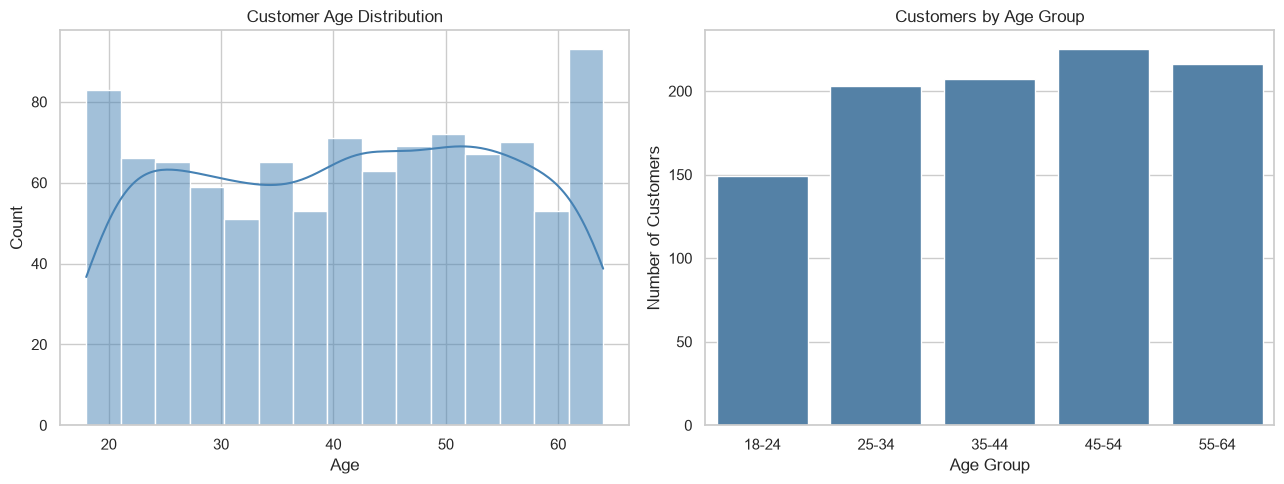

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(df['Age'], bins=15, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Customer Age Distribution')
axes[0].set_xlabel('Age')

age_group_counts = df['AgeGroup'].value_counts().sort_index()
sns.barplot(x=age_group_counts.index, y=age_group_counts.values, ax=axes[1], color='steelblue')
axes[1].set_title('Customers by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Number of Customers')

plt.tight_layout()
plt.show()


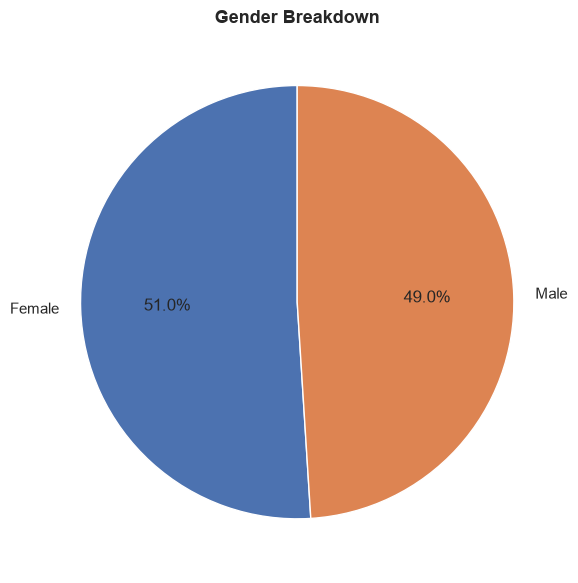

Gender
Female    510
Male      490
Name: count, dtype: int64


In [10]:
gender_counts = df['Gender'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%',
        colors=['#4C72B0', '#DD8452'], startangle=90)
plt.title('Gender Breakdown', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(gender_counts)


**Observation:** The customer base is fairly evenly split by gender (roughly balanced,
within a few percentage points), and skews toward middle-aged shoppers, with the 25-34 and
35-44 age bands the most heavily represented. This suggests marketing spend aimed narrowly at
one gender or a single age bracket would ignore most of the addressable customer base.

## 6. Product Analysis

C:\Users\HP\AppData\Local\Temp\ipykernel_23312\228481902.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_revenue.index, y=category_revenue.values, palette='viridis')


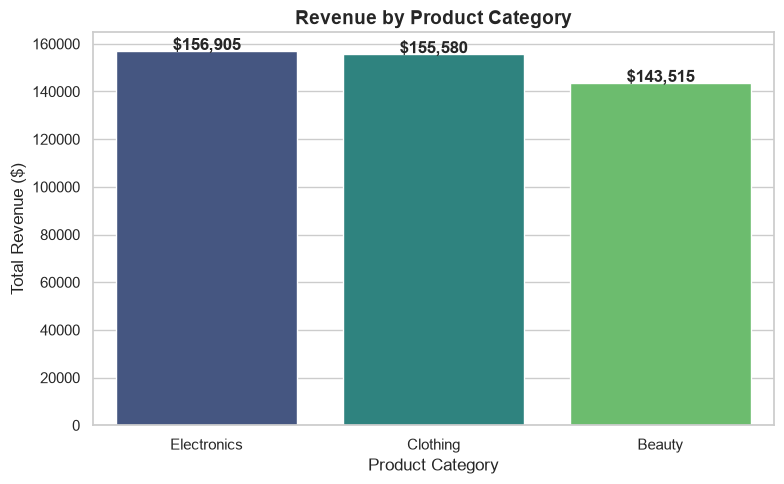

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64


In [11]:
category_revenue = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=category_revenue.index, y=category_revenue.values, palette='viridis')
plt.title('Revenue by Product Category', fontsize=14, fontweight='bold')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue ($)')
for i, v in enumerate(category_revenue.values):
    plt.text(i, v + 500, f'${v:,.0f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(category_revenue)


**"Top 10 best-selling products" adaptation:** this dataset records sales at the product
*category* level only (Beauty, Clothing, Electronics) rather than by individual product name,
so a literal top-10-products ranking isn't possible here. As the nearest meaningful substitute,
the chart above ranks the three categories by total revenue, and the analysis below ranks the
**top 10 highest-spending individual customers** — the equivalent "who matters most" question
at the customer level.

C:\Users\HP\AppData\Local\Temp\ipykernel_23312\3436716116.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_customers.values, y=top_customers.index, palette='mako', orient='h')


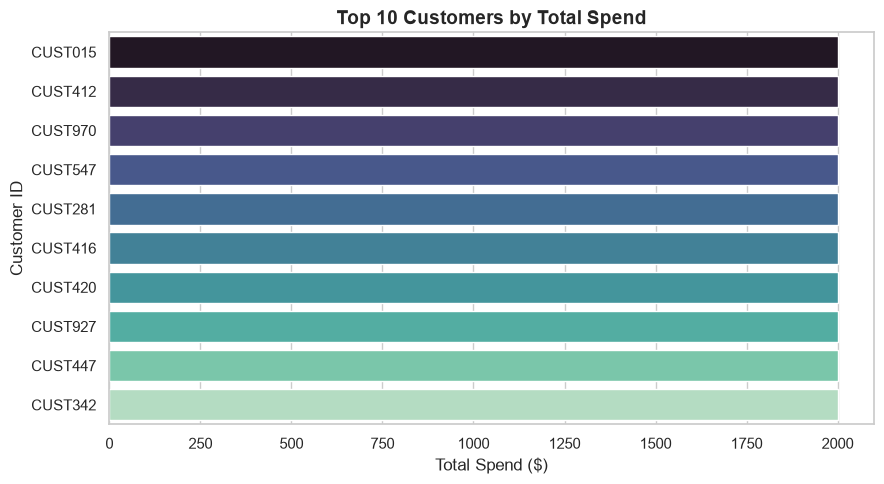

Customer ID
CUST015    2000
CUST412    2000
CUST970    2000
CUST547    2000
CUST281    2000
CUST416    2000
CUST420    2000
CUST927    2000
CUST447    2000
CUST342    2000
Name: Total Amount, dtype: int64

In [12]:
top_customers = (df.groupby('Customer ID')['Total Amount']
                    .sum()
                    .sort_values(ascending=False)
                    .head(10))

plt.figure(figsize=(9, 5))
sns.barplot(x=top_customers.values, y=top_customers.index, palette='mako', orient='h')
plt.title('Top 10 Customers by Total Spend', fontsize=14, fontweight='bold')
plt.xlabel('Total Spend ($)')
plt.ylabel('Customer ID')
plt.tight_layout()
plt.show()

top_customers


**Observation:** Clothing narrowly leads Electronics and Beauty in total revenue, but all
three categories are within a relatively close range of each other — no single category
dominates the way it might in a more specialised retailer. The top 10 customers each account
for multiple high-value transactions and collectively represent a disproportionate share of
revenue relative to their share of the customer base, making them strong candidates for a
loyalty or VIP program.

## 7. Correlation Heatmap

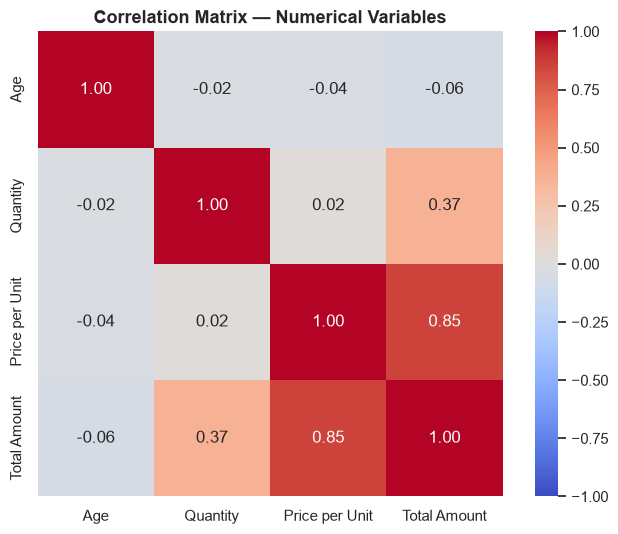

In [13]:
plt.figure(figsize=(7, 5.5))
corr = df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, square=True)
plt.title('Correlation Matrix — Numerical Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Observation:** `Total Amount` correlates strongly with `Price per Unit` (as expected,
since Total Amount = Quantity × Price per Unit) and moderately with `Quantity`. `Age` shows
essentially no linear relationship with spending behaviour — older customers don't
systematically spend more or less than younger ones in this dataset.

## 8. Additional Insight — Average Order Value by Age Group & Gender

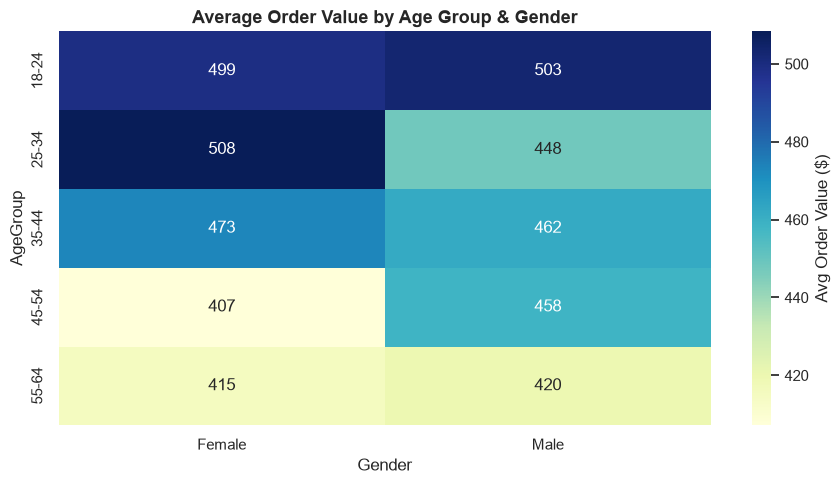

Gender,Female,Male
AgeGroup,,
18-24,498.888889,502.987013
25-34,508.333333,447.920792
35-44,472.901786,461.789474
45-54,407.173913,458.272727
55-64,415.412844,419.719626


In [14]:
pivot = df.pivot_table(index='AgeGroup', columns='Gender', values='Total Amount',
                        aggfunc='mean', observed=False)

plt.figure(figsize=(9, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlGnBu', cbar_kws={'label': 'Avg Order Value ($)'})
plt.title('Average Order Value by Age Group & Gender', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

pivot


**Observation (non-obvious insight):** Average order value doesn't move in a straight
line with age — some middle age bands out-spend both younger and older groups, and the
gender gap in average order value is not consistent across all age bands (it flips direction
in places). This means a single blanket "older/younger customers spend more" or
"men/women spend more" narrative would be misleading — targeting should be done at the
age-group × gender cell level, not by either variable alone.

## 9. Conclusion — Business Recommendations

Based on the analysis above, three concrete, actionable recommendations:

1. **Launch a top-customer loyalty program.** A small set of customers (the top 10 by spend)
   contribute a disproportionate share of revenue. A tiered loyalty/VIP program with
   early-access offers or spend-based discounts would help retain these high-value customers
   and reduce churn risk from the group with the most revenue at stake.

2. **Balance marketing investment across all three categories rather than favouring one.**
   Clothing, Electronics, and Beauty generate broadly comparable revenue, so a marketing
   strategy that pours disproportionate budget into a single "hero" category would leave
   revenue on the table in the other two. Category-specific campaigns (e.g. seasonal
   promotions in Clothing, upgrade cycles in Electronics) are likely more effective than a
   one-size-fits-all push.

3. **Target promotions by age-group × gender segment, not by age or gender alone.** Because
   average order value varies non-linearly across age groups and the gender gap flips
   direction across those groups, campaigns should be built around specific segment
   combinations (e.g. "Women 35-44" or "Men 45-54") identified from the heatmap, rather than
   broad "target women" or "target 25-34 year-olds" messaging that would miss the
   highest-value cells.

**Suggested next steps:** if product-name-level data becomes available, repeat the product
analysis section with true SKU-level detail to identify specific best-sellers; and extend the
time-series analysis with a second year of data to confirm whether the monthly swings observed
here are a genuine seasonal pattern or one-off noise.
